# Historical Assumptions and Guiding Question
Based on my historical knowledge, I make the assumption that prison populations in Southern States are way higher than other states, even though crime rates are not all that different. This ties back to policy making in the South based on the persistance of "tough on crime" politics, along with the history of Jim Crow laws. With this data set, I hope to visualize this and test to see if this is really the case, specifically from 2001-2016.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [60]:
crime = pd.read_csv("crime_and_incarceration_by_state.csv")

After loading my data in, I created a new list which conatined all states which I categorized as "South". I then created a new column named "region" which labeled each state to be "South" or "Non-South" based on the list. I then created another column named "total_crime" which added the totals from violent crimes and property crimes. This will allow me to compare prison counts to total crimes and not just violent or property crimes. I also removed the federal jurisdictioin since I am comparing states. 

In [61]:
southern_states = ["TEXAS", "ARKANSAS", "LOUISIANA", "MISSISSIPPI", "TENNESSEE", "KENTUCKY", "ALABAMA", "GEORGIA", "FLORIDA", "SOUTH CAROLINA", "NORTH CAROLINA", "VIRGINIA", "WEST VIRGINIA"]

crime = crime[crime["jurisdiction"] != "FEDERAL"].copy()

crime["region"] = np.where(crime['jurisdiction'].isin(southern_states), "South", "Non-South")

crime["total_crime"] = crime["violent_crime_total"] + crime["property_crime_total"]

crime.head()

,jurisdiction,includes_jails,year,prisoner_count,crime_reporting_change,crimes_estimated,state_population,violent_crime_total,murder_manslaughter,rape_legacy,rape_revised,robbery,agg_assault,property_crime_total,burglary,larceny,vehicle_theft,region,total_crime
1,ALABAMA,False,2001,24741,False,False,4468912.0,19582.0,379.0,1369.0,NaN,5584.0,12250.0,173253.0,40642.0,119992.0,12619.0,South,192835.0
2,ALASKA,True,2001,4570,False,False,633630.0,3735.0,39.0,501.0,NaN,514.0,2681.0,23160.0,3847.0,16695.0,2618.0,Non-South,26895.0
3,ARIZONA,False,2001,27710,False,False,5306966.0,28675.0,400.0,1518.0,NaN,8868.0,17889.0,293874.0,54821.0,186850.0,52203.0,Non-South,322549.0
4,ARKANSAS,False,2001,11489,False,False,2694698.0,12190.0,148.0,892.0,NaN,2181.0,8969.0,99106.0,22196.0,69590.0,7320.0,South,111296.0
5,CALIFORNIA,False,2001,157142,False,False,34600463.0,212867.0,2206.0,9960.0,NaN,64614.0,136087.0,1134189.0,232273.0,697739.0,204177.0,Non-South,1347056.0


After creating my new variables, I created summary to allow me to see the number of prisoners in comparison to the total crime and the difference in those two variabels between the two regions I created. However, I realized that just looking at these numbers does not really hold any significance for an audience. We can see that there is a higher number of prisoners in the South and there is more total crime in the South, but we cannot use these numbers to make a complete argument that crime or prisoners count is higher in the South since we are not seeing the proportion. To solve this, I created the incarceration rate variable so that we can see the true comparison. 

In [62]:
summary = crime.groupby("region")[["prisoner_count", "total_crime"]].mean() 

print(summary)

           prisoner_count    total_crime
region                                  
Non-South    20648.456081  178618.922166
South        38652.360577  314641.519231


In [63]:
crime["incarceration_rate"] = crime["prisoner_count"] / crime["total_crime"]

summary_ratio = crime.groupby("region")[["prisoner_count", "total_crime", "incarceration_rate"]].mean() 

print(summary_ratio)

           prisoner_count    total_crime  incarceration_rate
region                                                      
Non-South    20648.456081  178618.922166            0.117872
South        38652.360577  314641.519231            0.118771


We can see that the difference in incarceration rates between the South and non-South are not all that different. I created a bar chart so that this can be easier to visualize that there is marginal difference between the two regions. Although the incarceration rate is higher in the South, it is marginal. 

<function matplotlib.pyplot.show(close=None, block=None)>

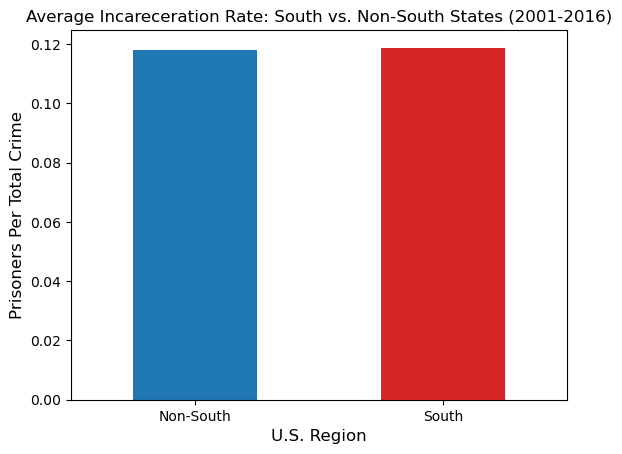

In [64]:
summary_ratio["incarceration_rate"].plot(kind = "bar", color = [ "#1f77b4", "#d62728"])
plt.title("Average Incareceration Rate: South vs. Non-South States (2001-2016)")
plt.ylabel("Prisoners Per Total Crime", fontsize = 12)
plt.xlabel("U.S. Region", fontsize = 12)
plt.xticks(rotation = 0)
plt.show

# Next Steps
After reflecting, I have realized that my original metrics that I used (prisoner_count/total_crime) does not really tell me how many people are inprisoned per crime committed. Doing this was only showing me  the probability that committing a crime would lead to being incarcerated. Since the South had more crimes, then the incarceration rate was higher, but it does not tell us the ratio to the entire population. With this in mind, I am moving forward with measuring the total number of prisoners divided by the total population of the state, and I am scaling it to a rate per 100,000 people for a better understanding. 

In [66]:
# crime.drop(columns=["incarceration_rate"], inplace=True)

region_totals = crime.groupby("region")[["prisoner_count", "state_population"]].sum()

region_totals["incarceration_rate_weight"] = (region_totals["prisoner_count"] / region_totals["state_population"]) * 100_000

print(region_totals)

           prisoner_count  state_population  incarceration_rate_weight
region                                                                
Non-South        12223886      3.228265e+09                 378.651847
South             8039691      1.623520e+09                 495.201178


This results shows that the South imprisoned 495 people per 100,000 residents compared to 379 in non-Southern states from 2001-2016. This is a gap of about 117 people per 100,000 meaning that for every 100,000 residents, the South incarcerates 117 more people than other regions of the country on average. Below is the percentage difference for better understanding. 

In [73]:
ratio = (region_totals["incarceration_rate_weight"]["South"] / region_totals["incarceration_rate_weight"]["Non-South"]) - 1

print(f"The South incarcerates {ratio:.1%} more per capita than other regions in the U.S.")

The South incarcerates 30.8% more per capita than other regions in the U.S.


<function matplotlib.pyplot.show(close=None, block=None)>

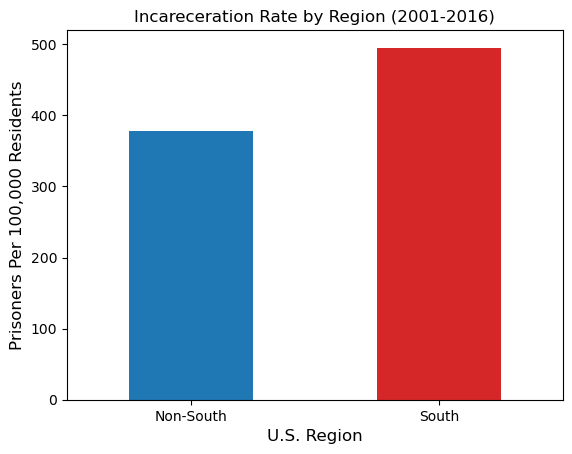

In [72]:
region_totals["incarceration_rate_weight"].plot(kind = "bar", color = [ "#1f77b4", "#d62728"])

plt.title("Incareceration Rate by Region (2001-2016)")
plt.ylabel("Prisoners Per 100,000 Residents", fontsize = 12)
plt.xlabel("U.S. Region", fontsize = 12)
plt.xticks(rotation = 0)
plt.show

For above, I need to find the national average so that I can compare. 

For my second graph, I was curious to see how this pattern held across time. My previous analysis only focused on the totals, so just one snapshot of the percentage differences. With a time series, I could look to see if this pattern held across the time frame of this data set (2001-2016). 

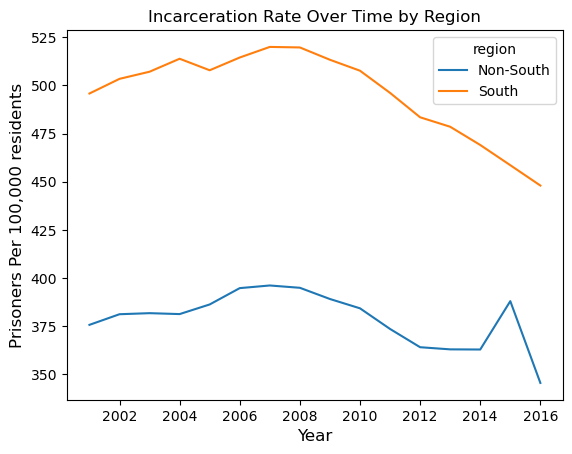

In [75]:
yearly = crime.groupby(["year", "region"])[["prisoner_count", "state_population"]].sum()
yearly["rate"] = (yearly["prisoner_count"] / yearly["state_population"]) * 100_000

yearly["rate"].unstack("region").plot()
plt.title("Incarceration Rate Over Time by Region")
plt.ylabel("Prisoners Per 100,000 residents", fontsize = 12)
plt.xlabel("Year", fontsize = 12)
plt.show()

Based on this graph, we can see that the South has consistently had higher incarceration rates compared to the rest of the nation throughout the entire 2001-2016 period. What I notice is that the gap between the two lines stays wide and stable, suggesting that the South's higher incarceration rate isn't just a temporary thing but rather a persistant structural difference. 

# Moving Forward and Further Analysis
